
## **1. IMPORT CÁC THỨ VIỆN CẦN THIẾT**







In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Kết nổi với drive để lấy file csv về
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **2. LOAD DATASET**

In [10]:
train_df = pd.read_csv("/content/drive/MyDrive/AI/titanic_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/AI/titanic_test.csv")

In [11]:
print("Dataset shape:", train_df.shape)



Dataset shape: (891, 12)


=> Dataset có tổng 891 hàng tương đương 891 khách hàng với 12 thuộc tính


# **3. DATA OVERVIEW**

3.1 XEM THÔNG TIN CỦA DATAFRAME

In [12]:
#Xem các cột của dataframe train_df
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [13]:
#Xem các cột của dataframe test_df
test_df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [14]:
#Set chỉ mục cho cột PassengerId
train_df.set_index(train_df.PassengerId,inplace=True)
#Xóa cột PassengerId không phải chỉ mục
train_df.drop("PassengerId",axis=1, inplace=True)
train_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
#Set chỉ mục cho cột PassengerId
test_df.set_index(test_df.PassengerId,inplace=True)
#Xóa cột PassengerId không phải chỉ mục
test_df.drop("PassengerId",axis=1, inplace=True)
test_df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [16]:
#Xem thông tin của dataframe train_df
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


Kết luận: Dataframe train_df có các cột Age, Cabin, Embarked bị thiếu dữ liệu
> Các cột Pclass, Sex, Embarked dạng categorical



> Các cột Age, Fare , SibSp, Parch dạng numerical



In [17]:
#Xem thông tin của dataframe test_df
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


Kết luận: Dataframe test_df có các cột Age, Fare, Cabin bị thiếu dữ liệu
> Các cột Pclass, Sex, Embarked dạng categorical



> Các cột Age, Fare , SibSp, Parch dạng numerical

 3.2 CHUYỂN ĐỔI DỮ LIỆU CÁC CỘT




In [18]:
#Chuyển đổi các cột thành kiểu category của hai dataframe
features= ["Pclass","Sex","Embarked"]
def convert_cat(df,features):
  for feature in features:
    df[feature]= df[feature].astype("category")
convert_cat(train_df,features)
convert_cat(test_df,features)
train_df.info()
test_df.info()




<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    category
 2   Name      891 non-null    object  
 3   Sex       891 non-null    category
 4   Age       714 non-null    float64 
 5   SibSp     891 non-null    int64   
 6   Parch     891 non-null    int64   
 7   Ticket    891 non-null    object  
 8   Fare      891 non-null    float64 
 9   Cabin     204 non-null    object  
 10  Embarked  889 non-null    category
dtypes: category(3), float64(2), int64(3), object(3)
memory usage: 65.6+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Pclass    418 non-null    category
 1   Name      418 non-null    object  
 2   Sex       418 non-null    category
 

3.3 THỐNG KÊ GIÁ TRỊ LÚC CHƯA ĐỦ DỮ LIỆU

In [19]:
#Dành cho các cột Numerical của train_df
train_df.describe()

,Survived,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,0.523008,0.381594,32.204208
std,0.486592,14.526497,1.102743,0.806057,49.693429
min,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
#Dành cho các cột Numerical của test_df
test_df.describe()

,Age,SibSp,Parch,Fare
count,332.000000,418.000000,418.000000,417.000000
mean,30.272590,0.447368,0.392344,35.627188
std,14.181209,0.896760,0.981429,55.907576
min,0.170000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,7.895800
50%,27.000000,0.000000,0.000000,14.454200
75%,39.000000,1.000000,0.000000,31.500000
max,76.000000,8.000000,9.000000,512.329200


In [21]:
#Dành cho các cột Categorical của train_df
train_df.describe(include="category")

,Pclass,Sex,Embarked
count,891,891,889
unique,3,2,3
top,3,male,S
freq,491,577,644


In [22]:
#Dành cho các cột Categorical của test_df
test_df.describe(include="category")

,Pclass,Sex,Embarked
count,418,418,418
unique,3,2,3
top,3,male,S
freq,218,266,270


# **4.	PREPROCESSING VALUES ANALYSIS**

4.1 TÍNH SỐ LƯỢNG / PHẦN TRĂM VALUES BỊ THIẾU Ở CÁC CỘT CATEGORICAL VÀ NUMERICAL


In [23]:
num_features=["Age","Fare"]
cat_features =["Pclass","Sex","Embarked","SibSp","Parch"]
feature_cols = num_features + cat_features
def display_missing(df,feature_cols):
  n_rows = len(df)
  for col in feature_cols:
    missing_count= df[col].isnull().sum()
    missing_rating = (missing_count / n_rows) * 100
    if missing_count > 0:
      print(f"Cột {col} có {missing_count} dữ liệu bị thiếu tương đương với {missing_rating:.2f}%")
display_missing(train_df,feature_cols)
display_missing(test_df,feature_cols)

Cột Age có 177 dữ liệu bị thiếu tương đương với 19.87%
Cột Embarked có 2 dữ liệu bị thiếu tương đương với 0.22%
Cột Age có 86 dữ liệu bị thiếu tương đương với 20.57%
Cột Fare có 1 dữ liệu bị thiếu tương đương với 0.24%


4.2 TRỰC QUAN HÓA MẤT MÁT DỮ LIỆU


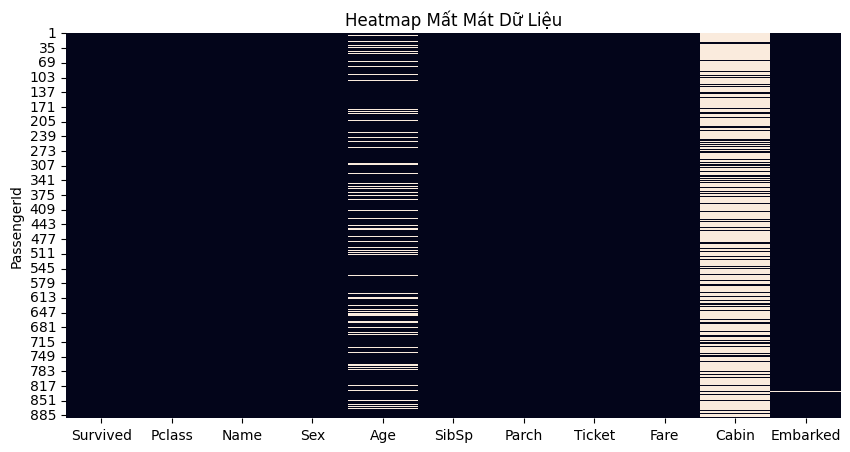

In [24]:
#Dataframe train_df
plt.figure(figsize=(10,5))
sns.heatmap(train_df.isnull(), cbar=False)
plt.title("Heatmap Mất Mát Dữ Liệu")
plt.show()

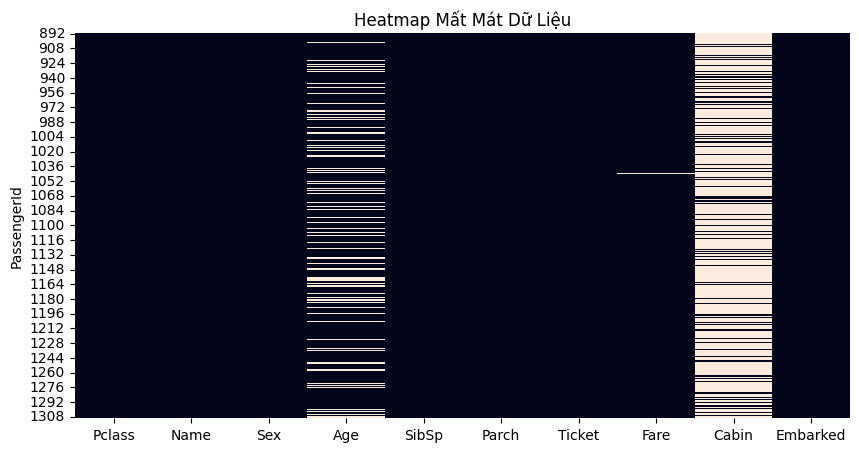

In [25]:
#Dataframe test_df
plt.figure(figsize=(10,5))
sns.heatmap(test_df.isnull(), cbar=False)
plt.title("Heatmap Mất Mát Dữ Liệu")
plt.show()

4.3 CHECK DỮ LIỆU TRÙNG LẮP

In [26]:
train_df.duplicated().sum()

np.int64(0)

=> Dataframe train_df không có dữ liệu trùng lắp

In [27]:
test_df.duplicated().sum()

np.int64(0)

=> Dataframe test_df không có dữ liệu trùng lắp

4.4 THÊM DỮ LIỆU BỊ THIẾU


In [28]:
#Thêm dữ liệu cột Age và Embarked dataframe train_df
train_df["Age"]= train_df["Age"].fillna(train_df["Age"].mean())
train_df["Embarked"] = train_df["Embarked"].fillna(train_df["Embarked"].mode()[0])
#Xóa dữ liệu cột Cabin vì mất dữ liệu quá nhiều
train_df = train_df.drop(columns=["Cabin"])
train_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    category
 2   Name      891 non-null    object  
 3   Sex       891 non-null    category
 4   Age       891 non-null    float64 
 5   SibSp     891 non-null    int64   
 6   Parch     891 non-null    int64   
 7   Ticket    891 non-null    object  
 8   Fare      891 non-null    float64 
 9   Embarked  891 non-null    category
dtypes: category(3), float64(2), int64(3), object(2)
memory usage: 58.7+ KB


In [29]:
#Thêm dữ liệu cột Age và Embarked dataframe train_df
test_df["Age"]= test_df["Age"].fillna(test_df["Age"].mean())
test_df["Fare"] = test_df["Fare"].fillna(test_df["Fare"].median())
#Xóa dữ liệu cột Cabin vì mất dữ liệu quá nhiều
test_df = test_df.drop(columns=["Cabin"])
test_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Pclass    418 non-null    category
 1   Name      418 non-null    object  
 2   Sex       418 non-null    category
 3   Age       418 non-null    float64 
 4   SibSp     418 non-null    int64   
 5   Parch     418 non-null    int64   
 6   Ticket    418 non-null    object  
 7   Fare      418 non-null    float64 
 8   Embarked  418 non-null    category
dtypes: category(3), float64(2), int64(2), object(2)
memory usage: 24.5+ KB


4.5 CHECK OUTLIERS CỦA CÁC CỘT NUMERICAL

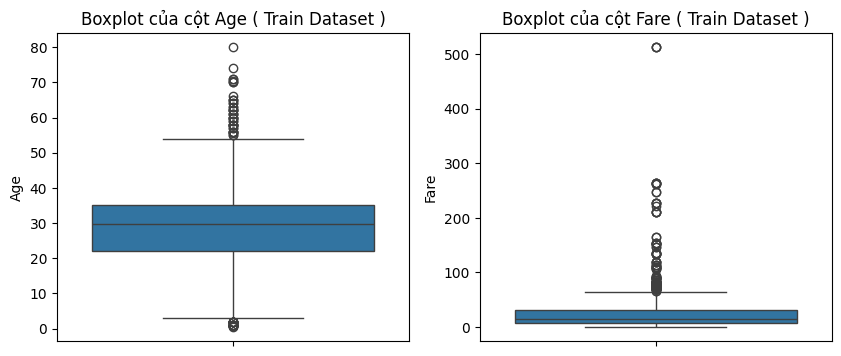

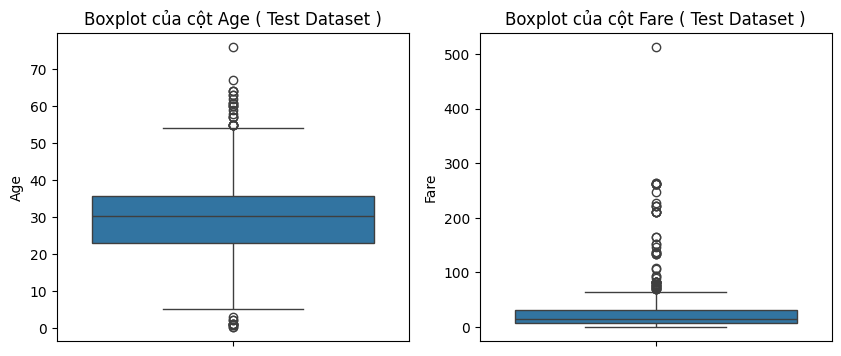

In [30]:
num_features = ['Age','Fare']

def plot_boxplots(df, features,name):
    plt.figure(figsize=(10,4))
    pos = 1
    for row in range(1):
        for col in range(len(features)):
            plt.subplot(1, len(features), pos)
            feature = features[col]
            sns.boxplot(y=df[feature])
            plt.title(f"Boxplot của cột {feature} ( {name} )")
            pos += 1
    plt.show()
plot_boxplots(train_df, num_features, "Train Dataset")
plot_boxplots(test_df, num_features, "Test Dataset")

# **5.UNIVARIATE ANALYSIS**

5.1 CÁC CỘT CATEGORICAL

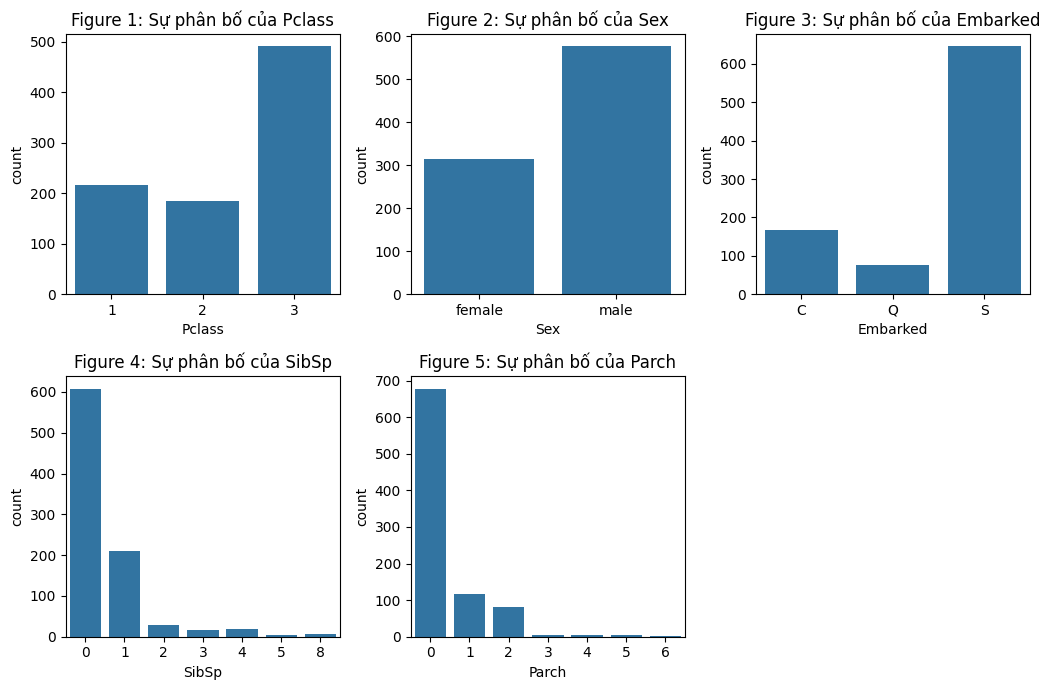

In [31]:

cate_features =['Pclass','Sex','Embarked','SibSp','Parch']
n_rows = 2
n_cols= 3
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.5, n_rows*3.5))
for r in range(0, n_rows):
  for c in range(0,n_cols):
    i = r*n_cols + c
    if i < len(cate_features):
      ax_i = ax[r,c]
      #Vẽ biểu đồ
      sns.countplot(data=train_df, x=cate_features[i], ax=ax_i)
      #Set tiêu đề cho mỗi subplot
      ax_i.set_title(f"Figure {i+1}: Sự phân bố của {cate_features[i]}")
ax.flat[-1].set_visible(False) # Ẩn subplot cuối
plt.tight_layout()

NHẬN XÉT:


> Biểu đồ cho thấy hành khách hạng 3 (Pclass = 3) chiếm tỷ lệ lớn nhất trong dataset, khoảng hơn một nửa tổng số hành khách, trong khi hạng 1 và hạng 2 có số lượng thấp hơn đáng kể. Điều này phản ánh rằng phần lớn hành khách trên tàu Titanic thuộc tầng lớp trung lưu hoặc lao động với giá vé thấp


> Biểu đồ phân bố giới tính cho thấy số lượng hành khách nam nhiều hơn nữ khá rõ rệt, chiếm khoảng hai phần ba tổng số hành khách trong dataset. Điều này phản ánh đặc điểm xã hội của thời kỳ đó khi nam giới thường chiếm phần lớn trong các chuyến đi dài hoặc di cư


> Biểu đồ cho thấy phần lớn hành khách lên tàu tại cảng Southampton (S), chiếm tỷ lệ áp đảo so với hai cảng còn lại là Cherbourg (C) và Queenstown (Q). Điều này phù hợp với lịch sử khi Titanic khởi hành từ Southampton nên số hành khách tại đây nhiều nhất


> Biểu đồ cho thấy đa số hành khách đi một mình, trong khi các gia đình lớn trên tàu là tương đối ít


> Biểu đồ cho thấy phần lớn hành khách không đi cùng gia đình trực hệ trên tàu









5.2 CÁC CỘT NUMERICAL


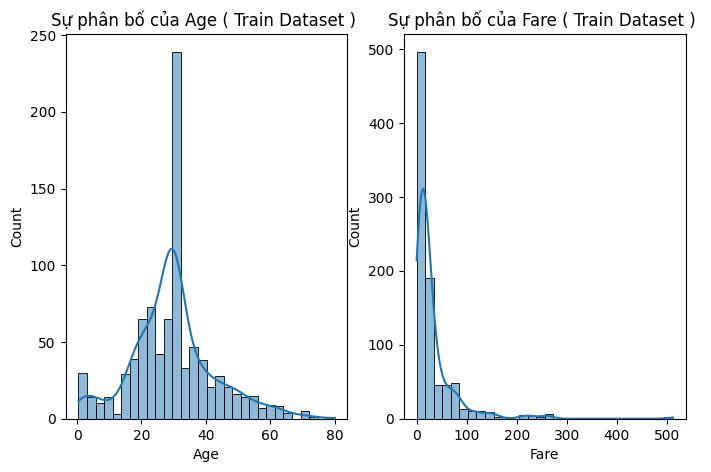

In [44]:
num_features =['Age','Fare']
def hisplot_features(df, features, name):
    plt.figure(figsize=(8,5))
    pos = 1
    for row in range(1):
        for col in range(len(features)):
            feature = features[col]
            plt.subplot(1, len(features), pos)
            sns.histplot(data = df, x =df[feature], bins=30, kde=True)
            plt.title(f"Sự phân bố của {feature} ( {name} ) ")
            pos += 1
    plt.show()
hisplot_features(train_df,num_features, "Train Dataset")


NHẬN XÉT:

> Về Age: cho thấy độ tuổi hành khách tập trung chủ yếu trong khoảng 20–40 tuổi, với đỉnh phân bố khoảng 25–30 tuổi, cho thấy phần lớn hành khách là người trưởng thành trẻ. Số lượng trẻ em và người cao tuổi khá ít, và số người giảm dần khi tuổi tăng. Phân bố Age hơi lệch phải, cho thấy vẫn tồn tại một số hành khách lớn tuổi nhưng không nhiều


> Về Fare: có dạng lệch trái mạnh, nghĩa là phần lớn hành khách có giá vé thấp (dưới khoảng 50), trong khi chỉ có một số ít hành khách trả giá vé rất cao, tạo thành các outliers ở phía bên phải của phân bố. Điều này phản ánh sự chênh lệch lớn về điều kiện kinh tế giữa các hành khách trên tàu




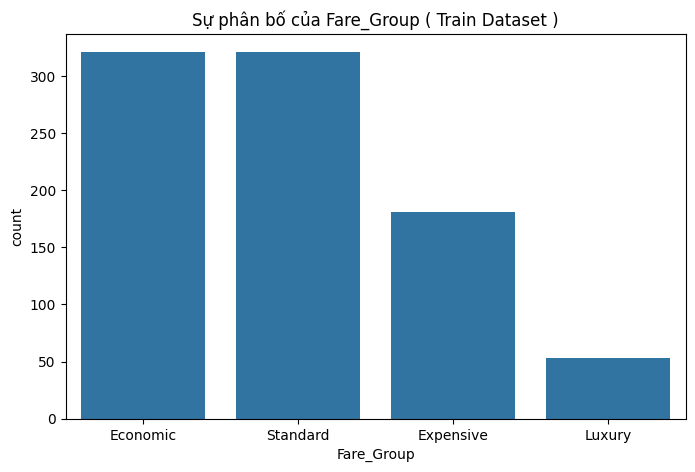

In [40]:
#Cột Fare được gom nhóm
def create_fare_group(df,name):
  plt.figure(figsize=(8,5))
  df["Fare_Group"] = pd.cut(
      df["Fare"],
      bins=[0,10,30,100,600],
      labels=["Economic","Standard","Expensive","Luxury"]
  )
  sns.countplot(data = df, x= df["Fare_Group"])
  plt.title(f"Sự phân bố của Fare_Group ( {name} )")
create_fare_group(train_df,"Train Dataset")


NHẬN XÉT: Sau khi gom nhóm giá vé thành Economic, Standard, Expensive và Luxury,phần lớn hành khách nằm trong hai nhóm Economic và Standard, với số lượng gần tương đương nhau và chiếm đa số trong dataset. Nhóm Expensive có số lượng ít hơn đáng kể, trong khi Luxury là nhóm nhỏ nhất với rất ít hành khách. Điều này cho thấy đa số hành khách trên tàu Titanic thuộc tầng lớp có mức chi trả thấp hoặc trung bình, trong khi hành khách có điều kiện kinh tế cao chỉ chiếm một tỷ lệ nhỏ

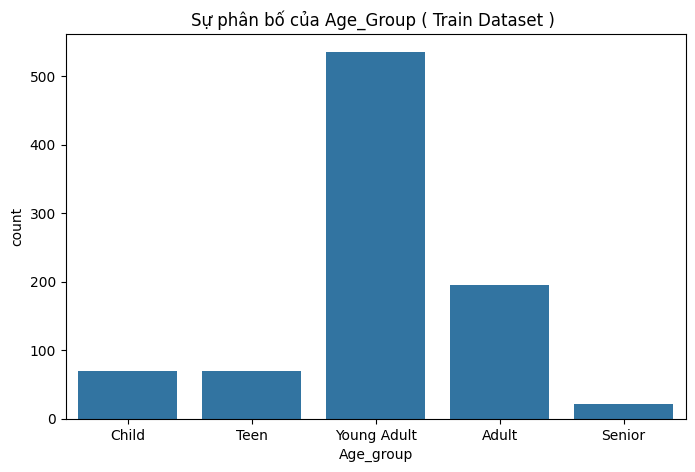

In [41]:
#Cột Age được gom nhóm
def create_age_group(df,name):
  plt.figure(figsize=(8,5))
  df["Age_group"] = pd.cut(
    df["Age"],
    bins=[0,12,18,35,60,100],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)
  sns.countplot(data = df, x= df["Age_group"])
  plt.title(f"Sự phân bố của Age_Group ( {name} ) ")
create_age_group(train_df, "Train Dataset")


NHẬN XÉT: Sau khi phân chia độ tuổi thành các nhóm Child, Teen, Young Adult, Adult và Senior, có thể thấy nhóm Young Adult (18–35 tuổi) chiếm số lượng lớn nhất, vượt trội so với các nhóm còn lại. Nhóm Adult (35–60 tuổi) đứng thứ hai nhưng thấp hơn khá nhiều so với Young Adult. Trong khi đó, các nhóm Child, Teen và đặc biệt là Senior có số lượng khá ít. Điều này cho thấy phần lớn hành khách trên tàu là những người trong độ tuổi trưởng thành trẻ

# **6. Bivariate Analysis**

6.1 CÁC CỘT CATEGORICAL

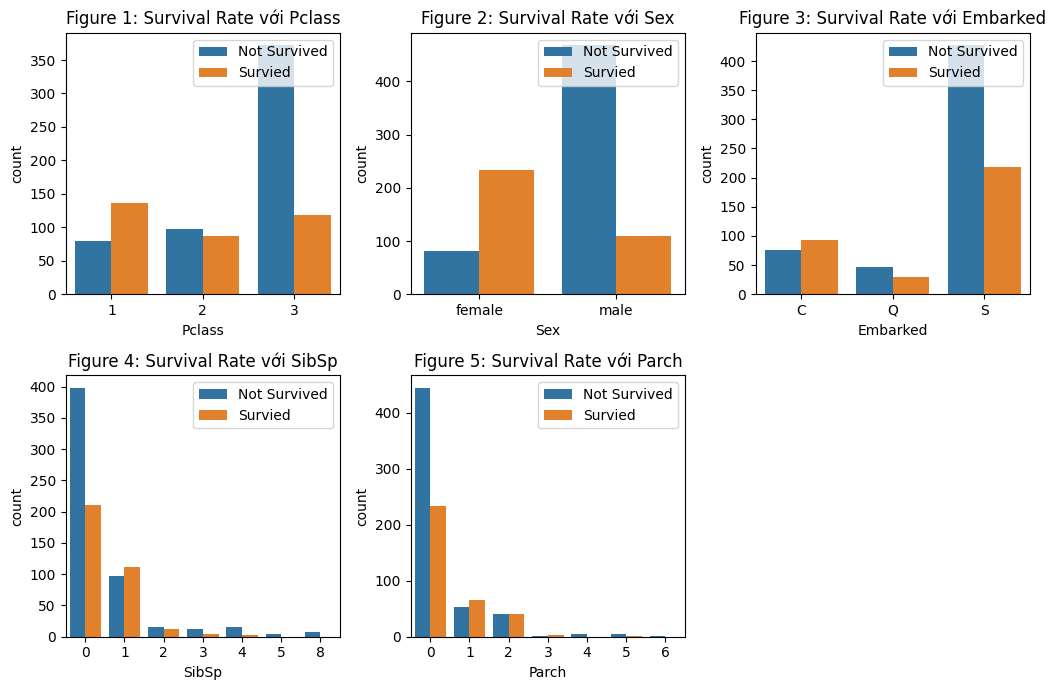

In [35]:
cols= ["Pclass","Sex","Embarked","SibSp","Parch"]
n_rows = 2
n_cols= 3
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.5, n_rows*3.5))
for r in range(0, n_rows):
  for c in range(0,n_cols):
    i = r*n_cols + c
    if i < len(cols):
      ax_i = ax[r,c]
      #Vẽ biểu đồ
      sns.countplot(data=train_df, x=cols[i],hue="Survived", ax=ax_i)
      #Set tiêu đề cho mỗi subplot
      ax_i.set_title(f"Figure {i+1}: Survival Rate với {cols[i]}")
      #Set chú thích cho mỗi subplot ( tiêu đề, vị trí, các nhãn)
      ax_i.legend(title ="", loc="upper right", labels=["Not Survived","Survied"])
ax.flat[-1].set_visible(False) # Ẩn subplot cuối
plt.tight_layout()

NHẬN XÉT:


> Về Pclass: Hành khách hạng 1 có số người sống sót nhiều hơn số người không sống sót, cho thấy khả năng sống sót của nhóm này khá cao. Ở hạng 2, số người sống và không sống gần tương đương nhau. Trong khi đó, hạng 3 có số người không sống sót vượt trội so với số người sống sót. Điều này cho thấy hạng vé có ảnh hưởng lớn đến khả năng sống sót, và hành khách ở hạng cao thường có điều kiện tốt hơn để tiếp cận thuyền cứu sinh

> Về Sex: Phụ nữ có số lượng sống sót cao hơn nhiều so với số người không sống, trong khi nam giới có số người không sống sót áp đảo so với số người sống. Điều này phản ánh quy tắc ưu tiên cứu hộ phụ nữ và trẻ em trước

> Về Embarked: hành khách lên tàu tại cảng Cherbourg (C) có tỷ lệ sống sót khá cao, khi số người sống gần hoặc cao hơn số người không sống. Ngược lại, ở Southampton (S), số người không sống sót nhiều hơn đáng kể so với số người sống. Queenstown (Q) có ít hành khách nên sự khác biệt không quá rõ ràng


> Về SipSb: phần lớn hành khách có SibSp = 0, tức là đi một mình, và trong nhóm này số người không sống sót nhiều hơn số người sống. Khi SibSp = 1, số người sống sót tăng lên đáng kể, cho thấy việc đi cùng một người thân có thể giúp tăng cơ hội sống sót. Tuy nhiên, khi số lượng người thân đi cùng quá nhiều (SibSp >= 3), số người sống sót giảm mạnh. Điều này cho thấy những gia đình quá đông có thể gặp khó khăn hơn trong việc thoát hiểm


> Về Parch: cho thấy việc đi cùng gia đình nhỏ có thể giúp tăng khả năng sống sót, nhưng các gia đình lớn lại có thể gặp khó khăn trong quá trình sơ tán












6.2 CÁC CỘT NUMERICAL

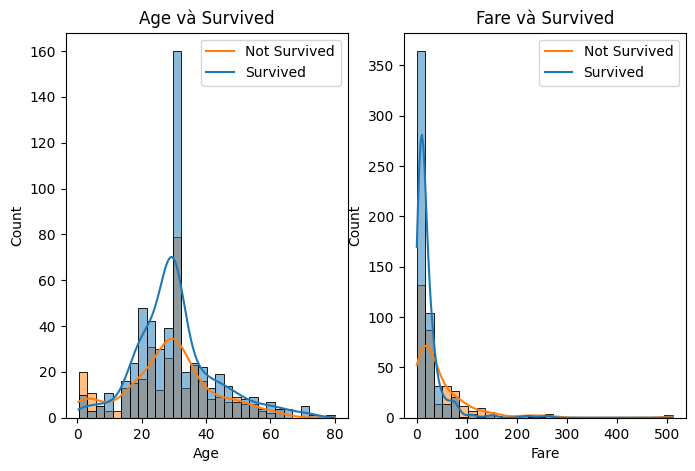

In [36]:
num_features =['Age','Fare']
def hisplot_features(df, features):
    plt.figure(figsize=(8,5))
    pos = 1
    for row in range(1):
        for col in range(len(features)):
            feature = features[col]
            plt.subplot(1, len(features), pos)
            sns.histplot(data = df, x =df[feature], bins=30, kde=True, hue="Survived")
            plt.title(f"{feature} và Survived")
            plt.legend(title="", labels=["Not Survived","Survived"])
            pos += 1
    plt.show()
hisplot_features(train_df,num_features)


NHẬN XÉT:


> Về Age: tập trung mạnh ở khoảng 20–40 tuổi, cho thấy đây là nhóm hành khách chính trên tàu. Trẻ em và người trẻ tuổi có xu hướng sống sót cao hơn, trong khi ở nhóm tuổi lớn (40+) số người không sống sót tăng dần, cho thấy tuổi tác vẫn có ảnh hưởng nhất định đến khả năng sống sót


> Về Fare: lệch trái rất mạnh, nghĩa là đa số hành khách mua vé giá thấp và chỉ một số ít trả vé rất cao. Ở vùng Fare thấp, số người không sống sót chiếm ưu thế, trong khi khi Fare tăng lên, đường phân bố của nhóm sống sót cao hơn rõ rệt. Điều này cho thấy hành khách trả vé cao có cơ hội sống sót tốt hơn, có thể do vị trí cabin tốt hơn, tiếp cận thuyền cứu sinh nhanh hơn hoặc được ưu tiên cứu hộ





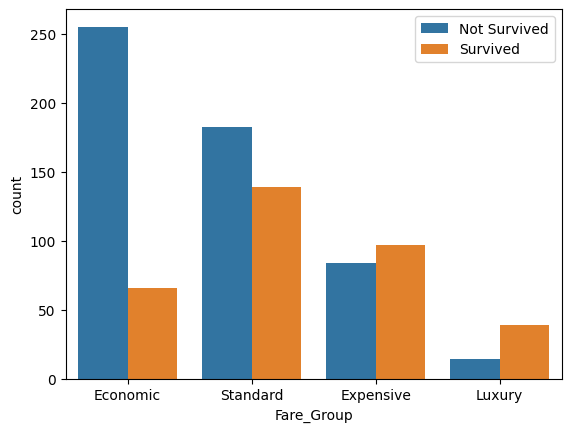

In [55]:
sns.countplot(data = train_df, x= train_df["Fare_Group"], hue="Survived")
plt.legend(title="",labels=['Not Survived','Survived'])

NHẬN XÉT:


> Biểu đồ Fare_Group và Survived cho thấy mối quan hệ khá rõ giữa giá vé và khả năng sống sót. Ở nhóm Economic, số người không sống sót vượt trội so với số người sống sót, cho thấy hành khách mua vé rẻ có cơ hội sống thấp hơn. Khi giá vé tăng lên (Standard, Expensive), khoảng cách giữa hai nhóm dần giảm và đến nhóm Expensive thì số người sống sót bắt đầu nhiều hơn


> Ở nhóm Luxury, mặc dù số lượng hành khách ít nhưng tỷ lệ sống sót cao hơn rõ rệt. Điều này cho thấy giá vé càng cao thì khả năng sống sót càng lớn, có thể do liên quan đến hạng khoang và vị trí thuận lợi hơn để tiếp cận thuyền cứu sinh





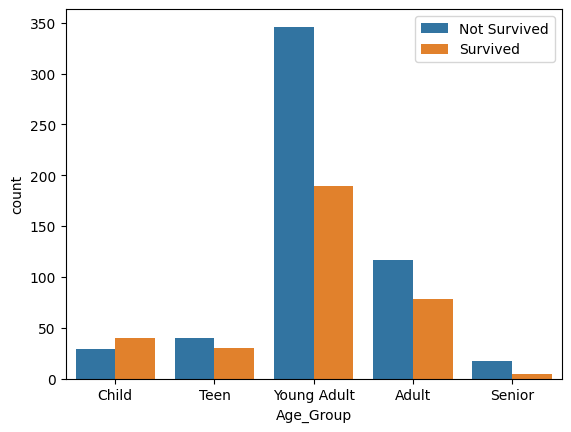

In [57]:
sns.countplot(data = train_df, x= train_df["Age_Group"], hue="Survived")
plt.legend(title="", labels=["Not Survived","Survived"])

NHẬN XÉT:


> Nhóm Child có số người sống sót nhiều hơn số không sống, cho thấy trẻ em thường được ưu tiên cứu hộ. Nhóm Teen có tỷ lệ sống và không sống khá gần nhau

> Trong khi đó, nhóm Young Adult và Adult chiếm phần lớn hành khách nhưng số người không sống sót nhiều hơn đáng kể, cho thấy người trưởng thành có tỷ lệ tử vong cao hơn


> Nhóm Senior có số lượng ít và đa phần không sống sót, có thể do hạn chế về thể lực khi sơ tán







# **7. FEATURE ENGINEERING**

7.1 Tạo cột Family Size

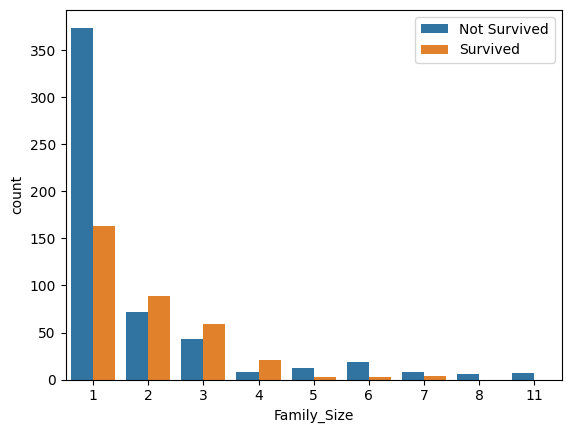

In [47]:
train_df["Family_Size"] = train_df["SibSp"].astype("int") + train_df["Parch"].astype("int") + 1
sns.countplot(data=train_df, x="Family_Size", hue="Survived")
plt.legend(title="",labels=['Not Survived','Survived'])

NHẬN XÉT:


> Phần lớn hành khách có Family_Size = 1 (đi một mình), và trong nhóm này số người không sống sót nhiều hơn đáng kể so với số người sống sót

>  Khi Family_Size tăng lên khoảng 2–4, số người sống sót bắt đầu cao hơn hoặc gần tương đương với số người không sống sót, cho thấy những hành khách đi cùng gia đình nhỏ có xu hướng có cơ hội sống sót tốt hơn, có thể do hỗ trợ lẫn nhau trong quá trình sơ tán


> uy nhiên, khi Family_Size quá lớn (>= 5), số người không sống sót tăng lên rõ rệt và số người sống sót rất ít. Điều này cho thấy gia đình quá đông có thể gặp khó khăn trong việc di chuyển và lên thuyền cứu sinh kịp thời






7.2 Tạo cột Family_Cat từ gom nhóm Family_Size

<Axes: xlabel='Family_Cat', ylabel='count'>

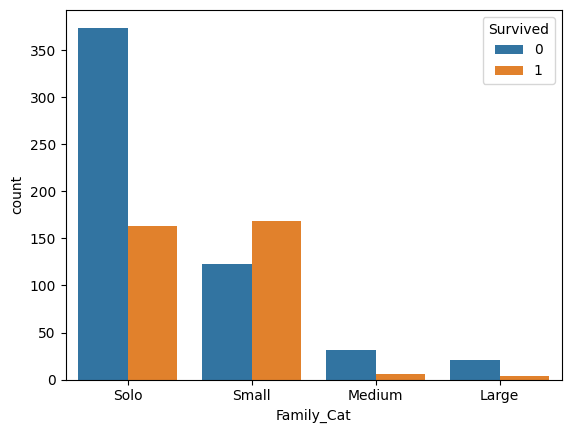

In [48]:
train_df["Family_Cat"]= pd.cut(train_df["Family_Size"], bins=[0,1,4,6,20], labels=["Solo","Small","Medium","Large"])
sns.countplot(data=train_df, x=train_df["Family_Cat"],hue="Survived")

# **8. CORRELATION MATRIX**

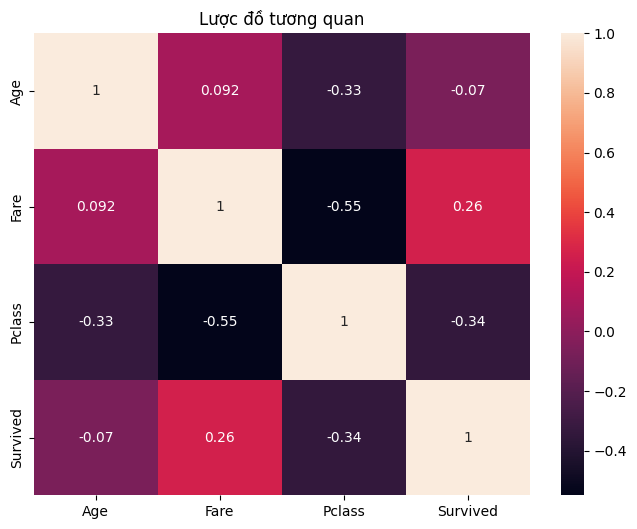

In [45]:
num_features = ["Age", "Fare", "Pclass"]
plt.figure(figsize=(8,6))
sns.heatmap(train_df[num_features + ["Survived"]].corr(),annot=True)
plt.title("Lược đồ tương quan")
plt.show()

NHẬN XÉT:


> Biến Survived có tương quan âm với Pclass (-0.34), cho thấy khi hạng vé thấp hơn thì khả năng sống sót giảm. Điều này cho thấy hành khách ở hạng cao  thường có cơ hội sống sót tốt hơn.

> Ngoài ra, Fare có tương quan dương với Survived (0.26), nghĩa là giá vé càng cao thì khả năng sống sót có xu hướng tăng, phù hợp với việc hành khách trả vé cao thường thuộc khoang tốt hơn


> Bên cạnh đó, Fare và Pclass có tương quan âm khá mạnh (-0.55), cho thấy hạng vé càng cao thì giá vé càng đắt


> Age có tương quan âm nhẹ với Pclass (-0.33), cho thấy hành khách lớn tuổi có xu hướng ở hạng vé cao hơn một chút







